In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

In [3]:
df = pd.read_csv('Breast Cancer Wisconsin (Diagnostic) Data Set.csv')

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.shape

(569, 33)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


### Data Cleaning 

In [7]:
df.isnull().sum().sort_values(ascending=False).head(10)

Unnamed: 32            569
id                       0
diagnosis                0
texture_mean             0
radius_mean              0
area_mean                0
smoothness_mean          0
compactness_mean         0
perimeter_mean           0
concave points_mean      0
dtype: int64

In [9]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

In [10]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

The target contains:

B → Benign

M → Malignant

In [11]:
df['diagnosis'] = df['diagnosis'].map({
    'B': 0,
    'M': 1
})

In [12]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


###  Exploratory Data Analysis

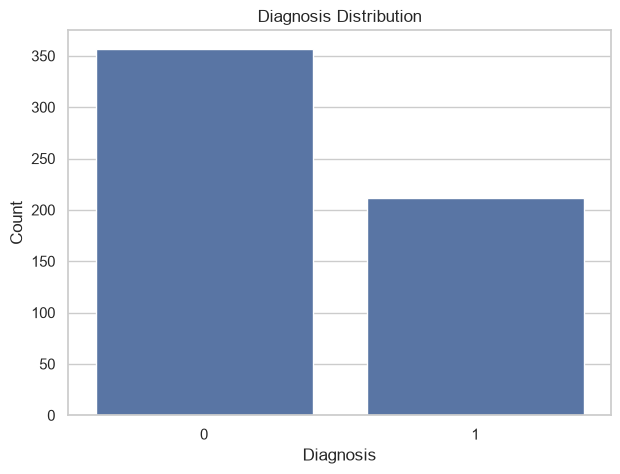

In [13]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='diagnosis')

plt.title('Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

plt.show()

### Correlation Heatmap

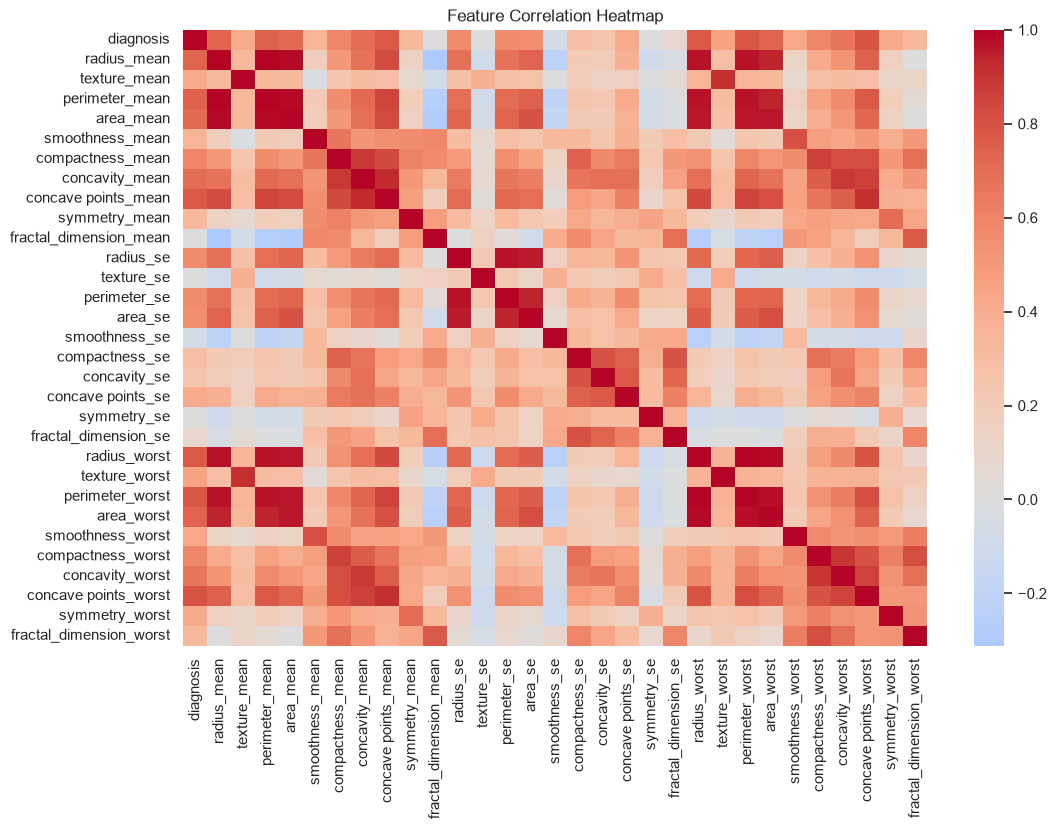

In [14]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Heatmap')

plt.show()

### Define X and y

X contains the input features.

y contains the target variable.

In [ ]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

In [16]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


### Train_Test Split

We will use:

80% → Training

20% → Testing

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [18]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [19]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

In [20]:
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [21]:
y_pred = dt_model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0]


In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)



Accuracy: 0.9298245614035088
Accuracy (%): 92.98245614035088


In [23]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9047619047619048


In [24]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.9047619047619048


In [25]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9047619047619048


In [26]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Benign', 'Malignant']
    )
)

              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [27]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[68  4]
 [ 4 38]]


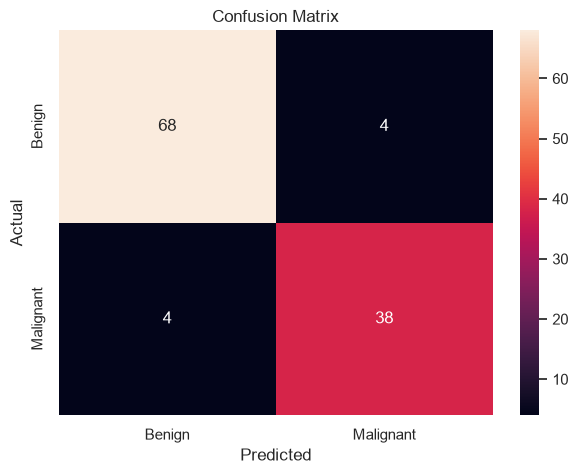

In [28]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

### 🔍 Interpretation
- True Negative (TN) = 68
  68 Benign cases were correctly predicted as Benign.
- False Positive (FP) = 4
  4 Benign cases were incorrectly predicted as Malignant.
- False Negative (FN) = 4
  4 Malignant cases were incorrectly predicted as Benign.
  ⚠️ In medical diagnosis, these are particularly important because the model failed to detect malignant cases.
- True Positive (TP) = 38
  38 Malignant cases were correctly predicted as Malignant.

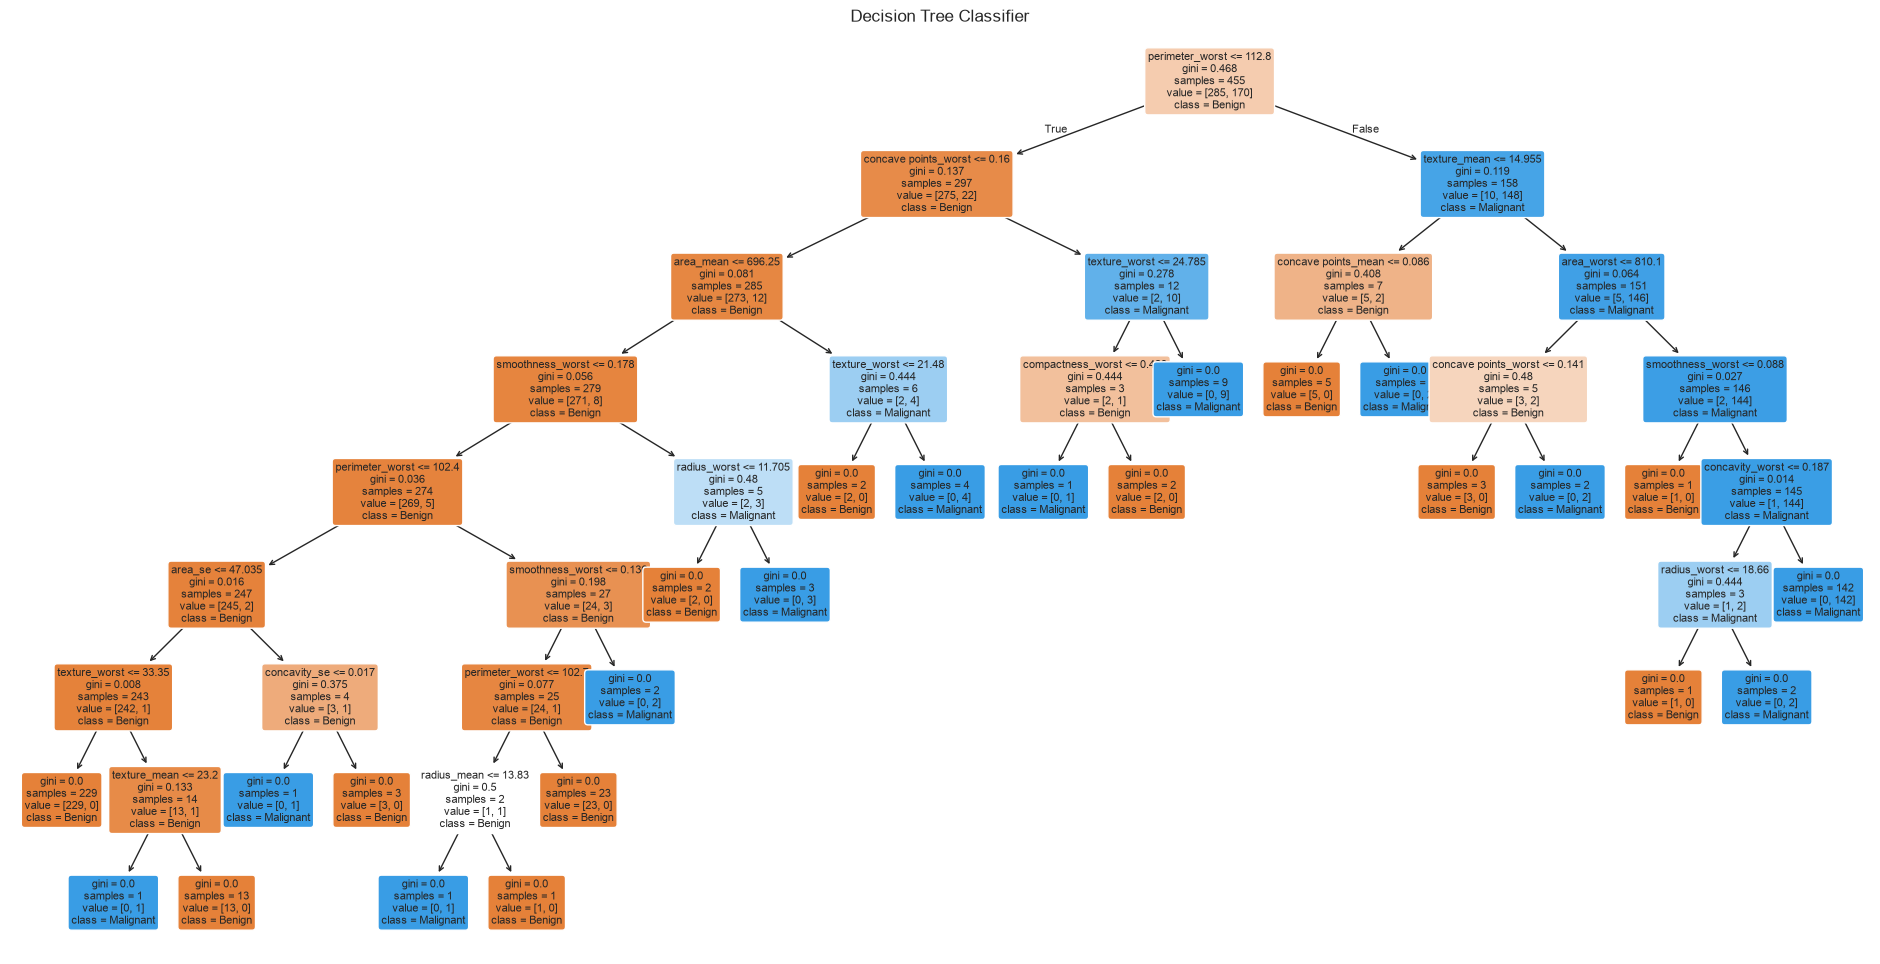

In [29]:
plt.figure(figsize=(24, 12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Benign', 'Malignant'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Decision Tree Classifier')

plt.show()

In [30]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
22,perimeter_worst,0.727477
27,concave points_worst,0.078970
24,smoothness_worst,0.040833
1,texture_mean,0.037871
21,texture_worst,0.022545
3,area_mean,0.022452
20,radius_worst,0.017530
23,area_worst,0.015606
7,concave points_mean,0.013416
16,concavity_se,0.007043


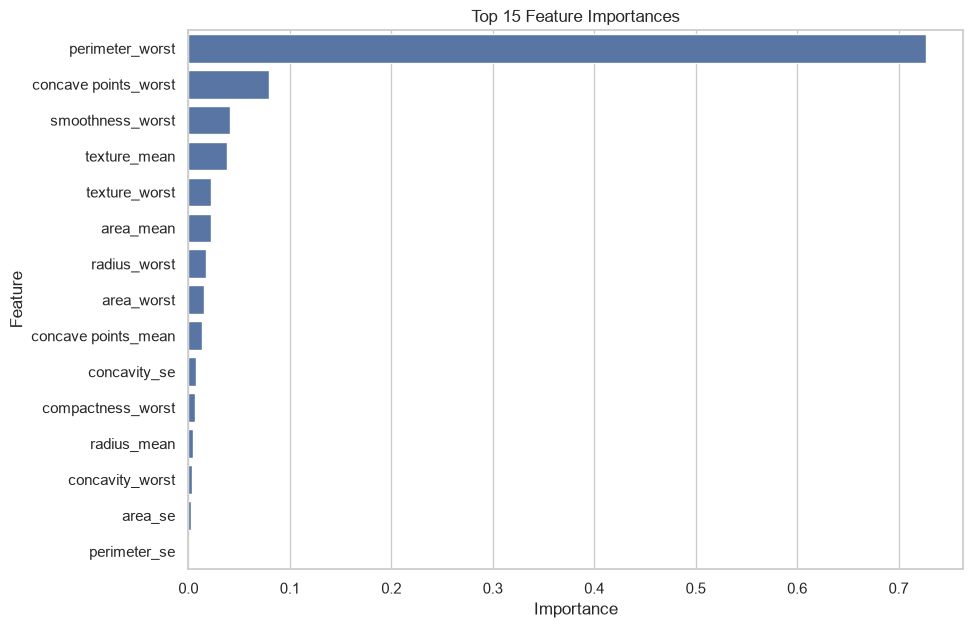

In [31]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

### Check Overfitting

Decision Trees can easily overfit when they become too deep.

Check training and testing accuracy:


In [32]:
train_accuracy = dt_model.score(X_train, y_train)

test_accuracy = dt_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9298245614035088


In [33]:
print("Tree Depth:", dt_model.get_depth())

print("Number of Leaves:", dt_model.get_n_leaves())

Tree Depth: 8
Number of Leaves: 24


### Control Tree Depth

Let's test different values of max_depth.

In [34]:
depths = range(1, 16)

train_scores = []
test_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(
        model.score(X_train, y_train)
    )

    test_scores.append(
        model.score(X_test, y_test)
    )

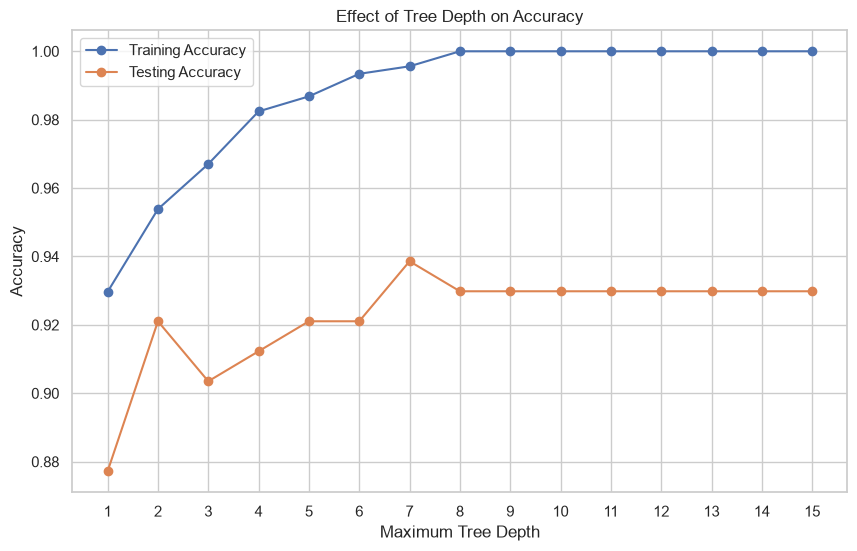

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_scores,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    depths,
    test_scores,
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel('Maximum Tree Depth')
plt.ylabel('Accuracy')

plt.title(
    'Effect of Tree Depth on Accuracy'
)

plt.legend()

plt.xticks(list(depths))

plt.show()

###  Hyperparameter Tuning

We can use GridSearchCV to find better Decision Tree parameters.

In [36]:
param_grid = {

    'criterion': [
        'gini',
        'entropy',
        'log_loss'
    ],

    'max_depth': [
        3,
        4,
        5,
        6,
        8,
        10,
        None
    ],

    'min_samples_split': [
        2,
        5,
        10
    ],

    'min_samples_leaf': [
        1,
        2,
        4
    ]
}

In [37]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1
)

In [38]:
grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.

In [39]:
print("Best Parameters:")

print(
    grid_search.best_params_
)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [40]:
print(
    "Best CV Accuracy:",
    grid_search.best_score_
)

Best CV Accuracy: 0.9494505494505494


### Final Tuned Decision Tree

In [41]:
best_dt = grid_search.best_estimator_

In [42]:
y_pred_best = best_dt.predict(X_test)

In [43]:
print(
    "Final Test Accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred_best
        ),
        4
    )
)

print(
    "Final Precision:",
    round(
        precision_score(
            y_test,
            y_pred_best
        ),
        4
    )
)

print(
    "Final Recall:",
    round(
        recall_score(
            y_test,
            y_pred_best
        ),
        4
    )
)

print(
    "Final F1 Score:",
    round(
        f1_score(
            y_test,
            y_pred_best
        ),
        4
    )
)

Final Test Accuracy: 0.9386
Final Precision: 1.0
Final Recall: 0.8333
Final F1 Score: 0.9091


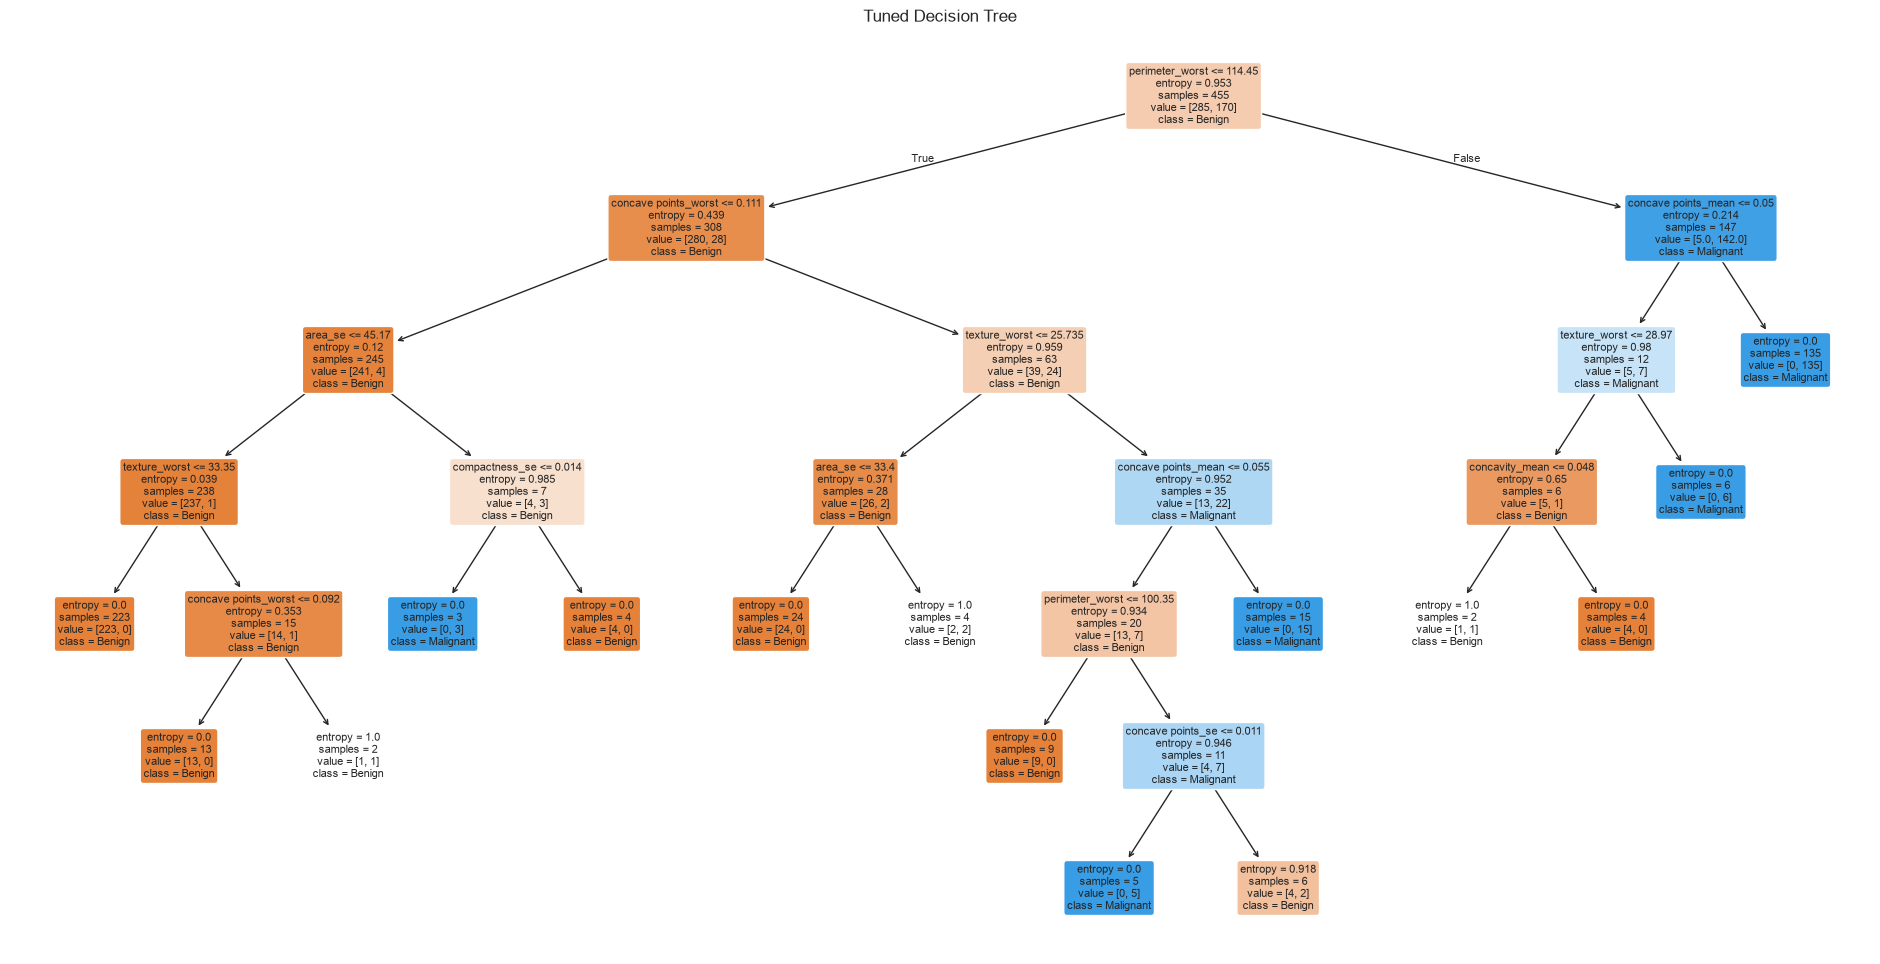

In [44]:
plt.figure(figsize=(24, 12))

plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=[
        'Benign',
        'Malignant'
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    'Tuned Decision Tree'
)

plt.show()

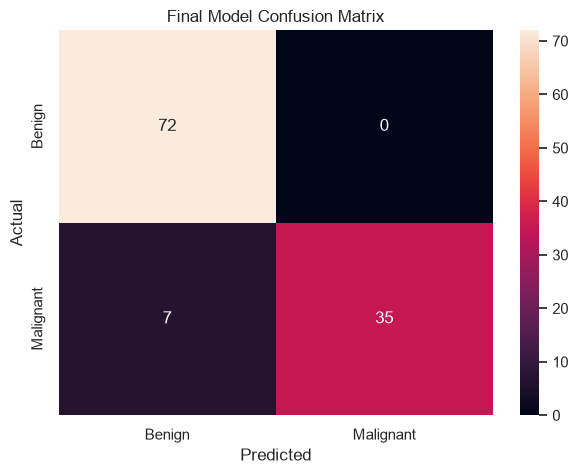

In [45]:
cm_best = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    xticklabels=[
        'Benign',
        'Malignant'
    ],
    yticklabels=[
        'Benign',
        'Malignant'
    ]
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title(
    'Final Model Confusion Matrix'
)

plt.show()

In [46]:
sample = X_test.iloc[[0]]

In [47]:
prediction = best_dt.predict(sample)[0]

In [48]:
if prediction == 1:
    result = "Malignant (M)"
else:
    result = "Benign (B)"

print("Predicted Diagnosis:", result)

Predicted Diagnosis: Benign (B)


In [49]:
print("========== DECISION TREE RESULTS ==========")

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            y_pred_best
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_best
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            y_pred_best
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            y_pred_best
        ),
        4
    )
)

print("============================================")

========== DECISION TREE RESULTS ==========
Accuracy : 0.9386
Precision: 1.0
Recall   : 0.8333
F1 Score : 0.9091
